Entrez la volatilité cible :  0.3


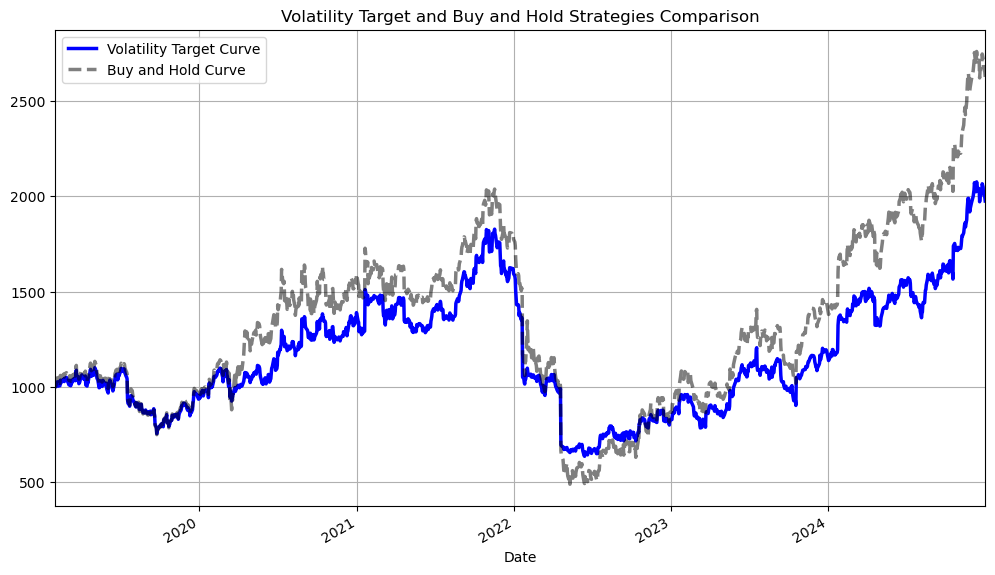

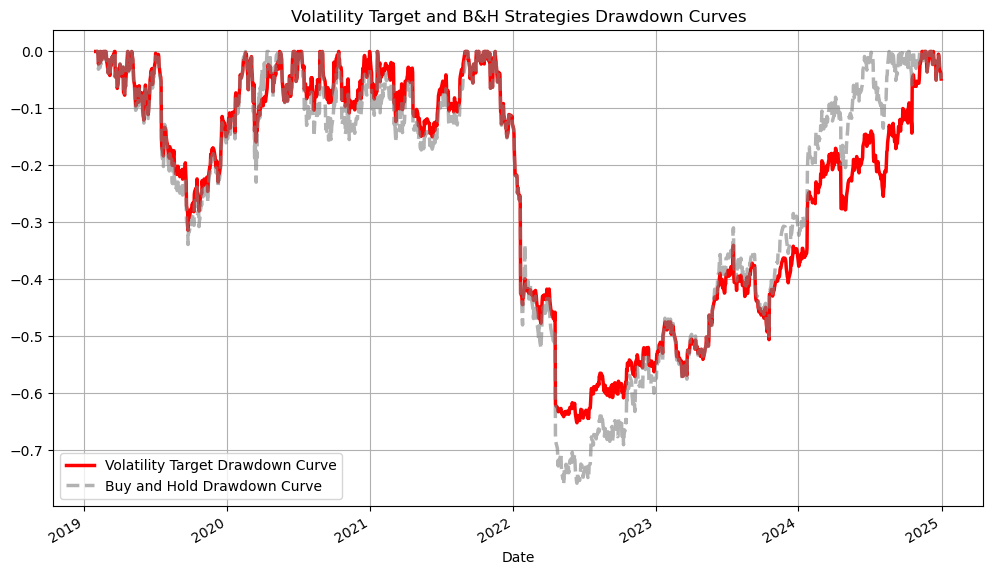

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Fonctions import compute_metrics, drawdown, vol_annu
%load_ext autoreload
%autoreload 2
data_return = pd.read_csv("NFLX_data_return.csv",index_col = 0, parse_dates = True).squeeze()
vol_roll = data_return.rolling(21).std()*np.sqrt(252)
V0=1000

sigma = float(input("Entrez la volatilité cible : "))
weight = sigma / vol_roll
weight = weight.clip(upper=1)
return_strat = weight.shift(1)*data_return
equity_curve = V0*np.exp(return_strat.cumsum())
equity_curve = equity_curve["2019-01-31":]
equity_curve = equity_curve / equity_curve.iloc[0] * V0
equity_bandh = V0 * np.exp(data_return.cumsum())
equity_bandh = equity_bandh["2019-01-31":]
equity_bandh = equity_bandh / equity_bandh.iloc[0] * V0

plt.figure(figsize=(12,7))
equity_curve.plot(color="blue",linewidth = 2.5, label = "Volatility Target Curve")
equity_bandh.plot(color="black", linewidth = 2.5, label = "Buy and Hold Curve",linestyle = '--', alpha = 0.5)
plt.title("Volatility Target and Buy and Hold Strategies Comparison")
plt.grid()
plt.legend()
plt.xlim(equity_curve.index[0], equity_curve.index[-1])
plt.show()
data_return_filtered = data_return["2019-01-31":]
strat_filtered = return_strat["2019-01-31":]

plt.figure(figsize = (12,7))
drawdown(equity_curve).plot(color = "red", linewidth = 2.5, label = "Volatility Target Drawdown Curve")
drawdown(equity_bandh).plot(color = "grey", linewidth = 2.5, linestyle = "--", label = "Buy and Hold Drawdown Curve", alpha = 0.6)
plt.title ("Volatility Target and B&H Strategies Drawdown Curves")
plt.grid()
plt.legend()
plt.show()

pd.DataFrame({
    "Volatility Target": compute_metrics(strat_filtered, equity_curve,freq="daily"),
    "Buy and Hold": compute_metrics(data_return_filtered, equity_bandh,freq="daily")
})
compute_metrics(strat_filtered, equity_curve, freq="daily").to_csv("metrics_voltarget.csv")